In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data.csv', encoding='unicode_escape')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [2]:
print(df.columns.tolist())
print(df.shape)

['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']
(541909, 8)


In [3]:
##  Checking for missing values

print(df.isnull().sum())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [4]:
##   Checking data types

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
None


In [5]:
##   Checking basic statistics

print(df.describe())

            Quantity      UnitPrice     CustomerID
count  541909.000000  541909.000000  406829.000000
mean        9.552250       4.611114   15287.690570
std       218.081158      96.759853    1713.600303
min    -80995.000000  -11062.060000   12346.000000
25%         1.000000       1.250000   13953.000000
50%         3.000000       2.080000   15152.000000
75%        10.000000       4.130000   16791.000000
max     80995.000000   38970.000000   18287.000000


In [6]:
## cleaning the data

In [7]:
##  Removeing cancelled orders

df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
print(df.shape)

(532621, 8)


In [8]:
##  Removeing negative quantities and prices

df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]
print(df.shape)

(530104, 8)


In [9]:
##  Drop missing CustomerID and Description

df = df.dropna(subset=['CustomerID', 'Description'])
print(df.shape)

(397884, 8)


In [10]:
##  Convert InvoiceDate to proper date format

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Month'] = df['InvoiceDate'].dt.month
df['Year'] = df['InvoiceDate'].dt.year
print(df['InvoiceDate'].head())

0   2010-12-01 08:26:00
1   2010-12-01 08:26:00
2   2010-12-01 08:26:00
3   2010-12-01 08:26:00
4   2010-12-01 08:26:00
Name: InvoiceDate, dtype: datetime64[ns]


In [11]:
##  Createing Total Revenue column

df['TotalRevenue'] = df['Quantity'] * df['UnitPrice']
print(df['TotalRevenue'].head())

0    15.30
1    20.34
2    22.00
3    20.34
4    20.34
Name: TotalRevenue, dtype: float64


In [12]:
##  Confirm everything is clean

print(df.isnull().sum())
print(df.shape)

InvoiceNo       0
StockCode       0
Description     0
Quantity        0
InvoiceDate     0
UnitPrice       0
CustomerID      0
Country         0
Month           0
Year            0
TotalRevenue    0
dtype: int64
(397884, 11)


In [13]:
## analyzing the data



In [14]:
##  Total overall revenue

total_revenue = df['TotalRevenue'].sum()
print(f'Total Revenue: ${total_revenue:,.2f}')

Total Revenue: $8,911,407.90


In [15]:
##   Top 10 countries by revenue

top_countries = df.groupby('Country')['TotalRevenue'].sum().sort_values(ascending=False).head(10)
print(top_countries)

Country
United Kingdom    7308391.554
Netherlands        285446.340
EIRE               265545.900
Germany            228867.140
France             209024.050
Australia          138521.310
Spain               61577.110
Switzerland         56443.950
Belgium             41196.340
Sweden              38378.330
Name: TotalRevenue, dtype: float64


In [16]:
##  Top 10 best selling products

top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
print(top_products)

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54415
JUMBO BAG RED RETROSPOT               46181
WHITE HANGING HEART T-LIGHT HOLDER    36725
ASSORTED COLOUR BIRD ORNAMENT         35362
PACK OF 72 RETROSPOT CAKE CASES       33693
POPCORN HOLDER                        30931
RABBIT NIGHT LIGHT                    27202
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64


In [17]:
##  Monthly revenue trend

monthly_revenue = df.groupby(['Year', 'Month'])['TotalRevenue'].sum()
print(monthly_revenue)

Year  Month
2010  12        572713.890
2011  1         569445.040
      2         447137.350
      3         595500.760
      4         469200.361
      5         678594.560
      6         661213.690
      7         600091.011
      8         645343.900
      9         952838.382
      10       1039318.790
      11       1161817.380
      12        518192.790
Name: TotalRevenue, dtype: float64


In [18]:
##   Top 10 customers by revenue

top_customers = df.groupby('CustomerID')['TotalRevenue'].sum().sort_values(ascending=False).head(10)
print(top_customers)

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194550.79
16446.0    168472.50
14911.0    143825.06
12415.0    124914.53
14156.0    117379.63
17511.0     91062.38
16029.0     81024.84
12346.0     77183.60
Name: TotalRevenue, dtype: float64


In [19]:
## Average order value

avg_order = df.groupby('InvoiceNo')['TotalRevenue'].sum().mean()
print(f'Average Order Value: ${avg_order:,.2f}')

Average Order Value: $480.87


In [20]:
## Visualization

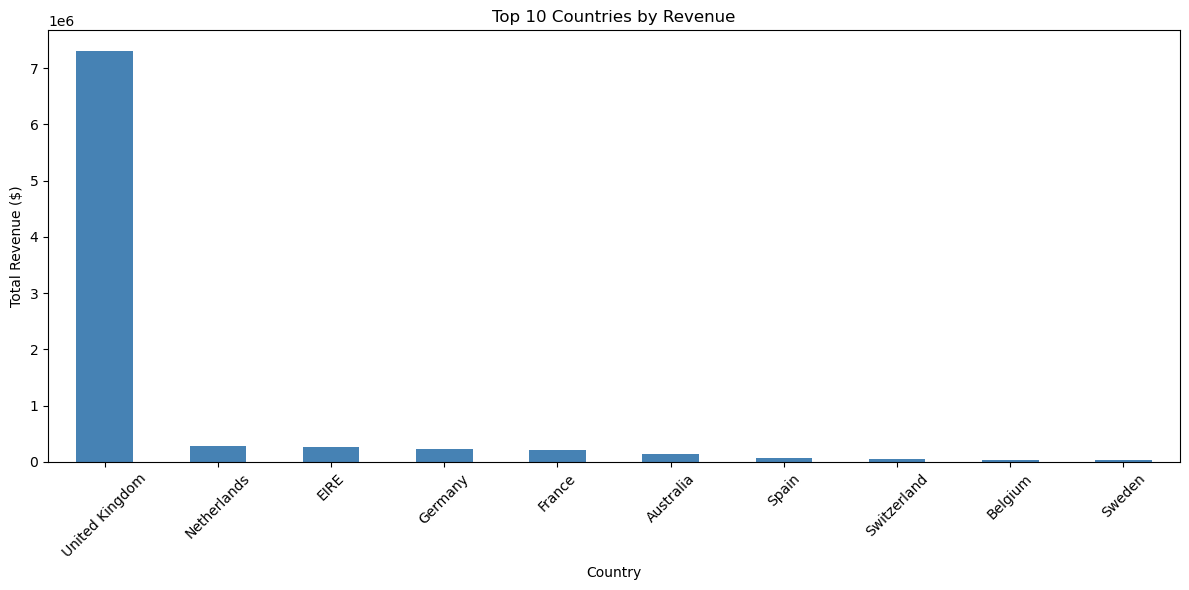

In [21]:
##   Top 10 Countries by Revenue (Bar Chart)

plt.figure(figsize=(12,6))
top_countries.plot(kind='bar', color='steelblue')
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Country')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

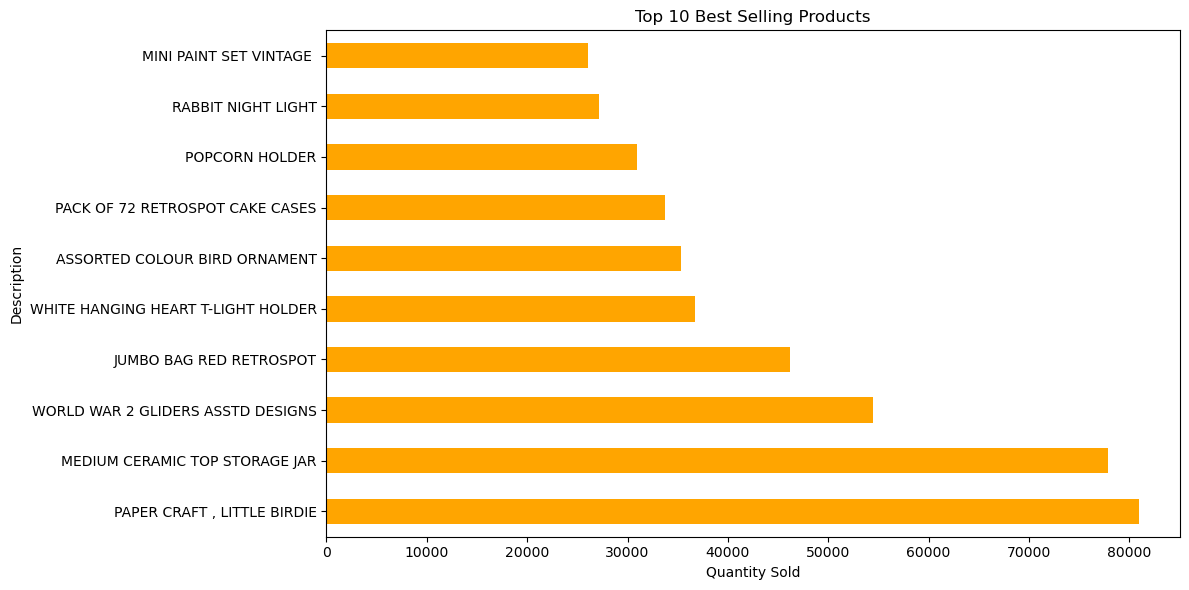

In [22]:
##  Top 10 Best Selling Products (Bar Chart)

plt.figure(figsize=(12,6))
top_products.plot(kind='barh', color='orange')
plt.title('Top 10 Best Selling Products')
plt.xlabel('Quantity Sold')
plt.tight_layout()
plt.show()

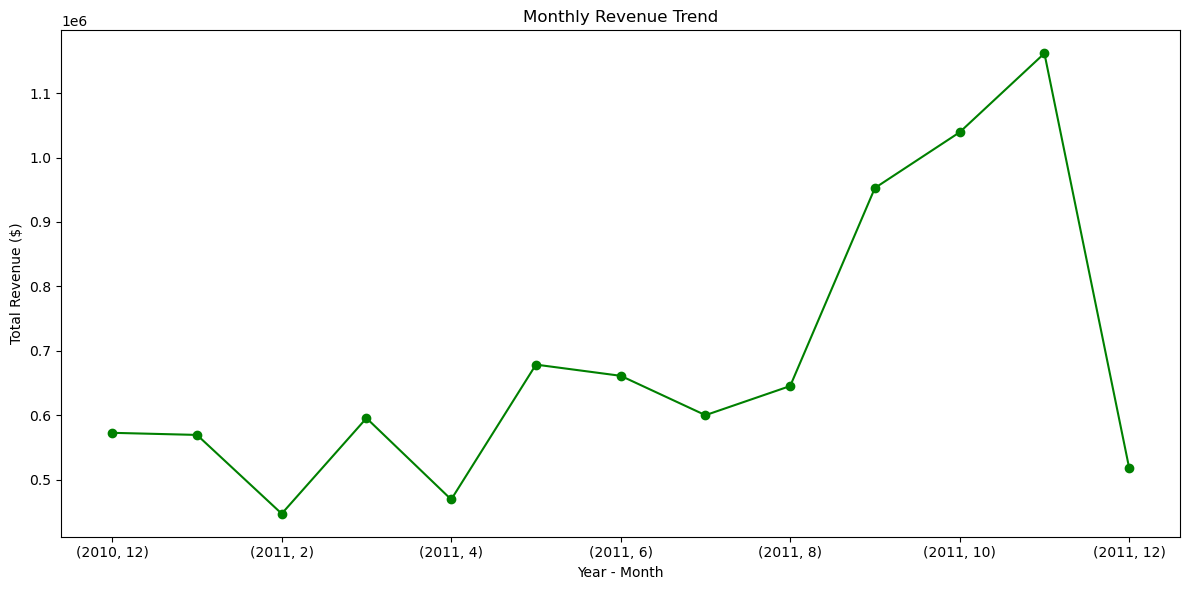

In [23]:
##  Monthly Revenue Trend (Line Chart)

plt.figure(figsize=(12,6))
monthly_revenue.plot(kind='line', color='green', marker='o')
plt.title('Monthly Revenue Trend')
plt.xlabel('Year - Month')
plt.ylabel('Total Revenue ($)')
plt.tight_layout()
plt.show()

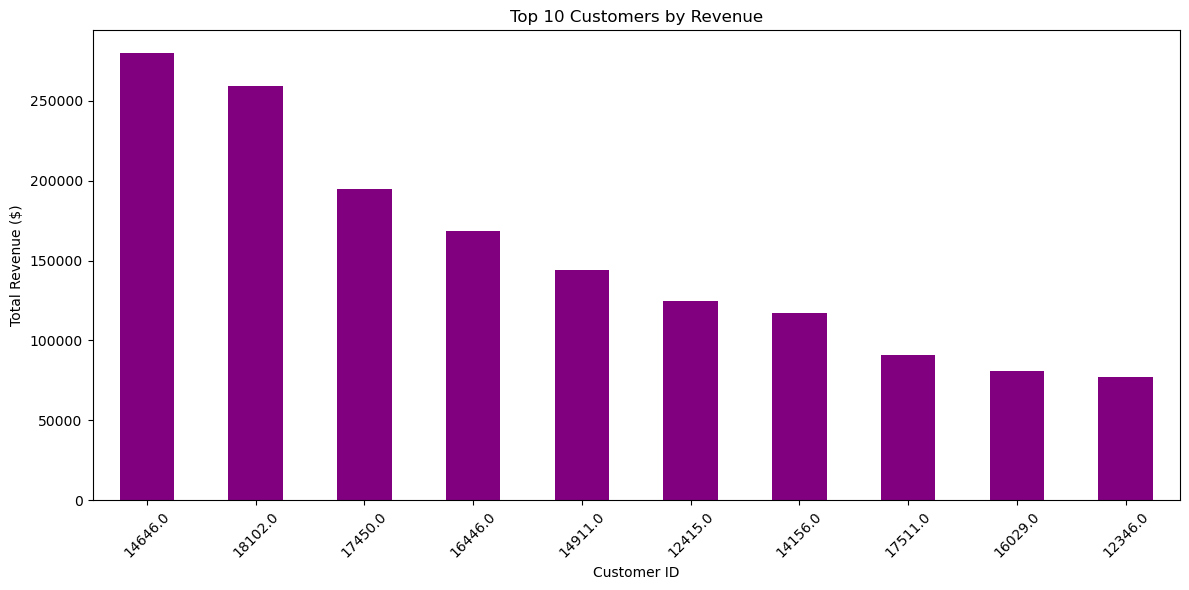

In [24]:
##  Top 10 Customers by Revenue (Bar Chart)

plt.figure(figsize=(12,6))
top_customers.plot(kind='bar', color='purple')
plt.title('Top 10 Customers by Revenue')
plt.xlabel('Customer ID')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [26]:
df.to_csv('ecommerce_cleaned.csv', index=False)
print('File saved successfully')

File saved successfully
